# Pricing Elasticity Analysis

## Exploratory Data Analysis (EDA)

### Objective
Explore the dataset to identify patterns, relationships, trends, and business insights that affect product demand and pricing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

# Plot style
plt.style.use("default")
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("../data/data/retail_price.csv")

## 1. Distribution of Quantity Sold

This plot shows how the quantity sold (`qty`) is distributed across all records.

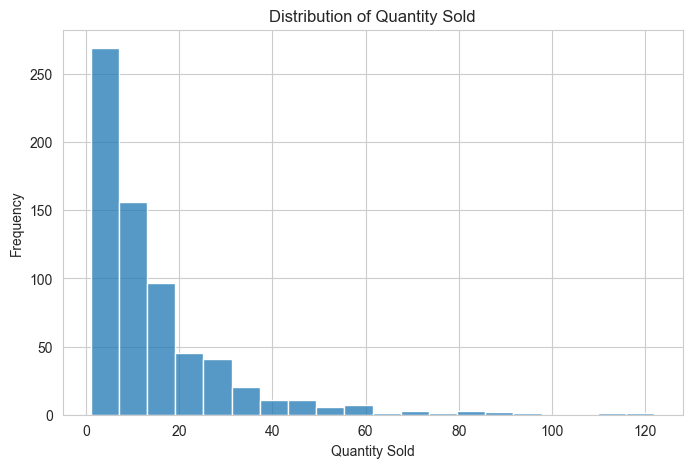

In [4]:
plt.figure(figsize=(8,5))

sns.histplot(df["qty"], bins=20)

plt.title("Distribution of Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Frequency")

plt.show()

### Insight

- The quantity sold is **right-skewed**, with most observations concentrated at lower sales values.
- Most products sell in relatively small quantities.
- Only a few products achieve very high sales, creating a long right tail.
- This indicates that demand is uneven across products, with a small number of products contributing disproportionately to total sales.


## 2. Distribution of Unit Price

Analyze how product prices are distributed.

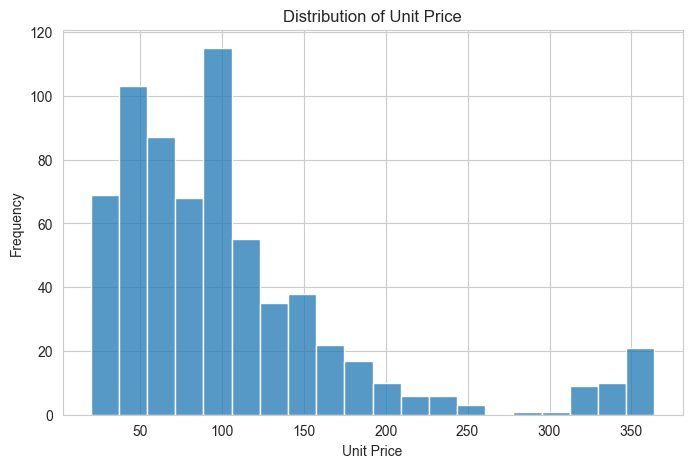

In [5]:
plt.figure(figsize=(8,5))

sns.histplot(df["unit_price"], bins=20)

plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")

plt.show()

### Insight

- Most products are priced between **40 and 120**.
- The distribution of unit prices is **right-skewed**, indicating that a few products have much higher prices.
- High-priced products are relatively uncommon compared to low- and medium-priced products.
- This suggests the store primarily focuses on affordable to mid-range products, with a smaller premium product segment.

## 3. Box Plot of Unit Price

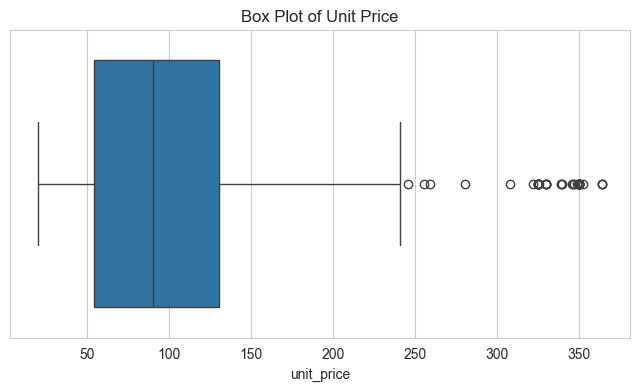

In [6]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["unit_price"])

plt.title("Box Plot of Unit Price")

plt.show()


### Insight

- The middle 50% of unit prices lie approximately between ₹55 and ₹130.
- The median unit price is around ₹90.
- Several high-price outliers are present beyond ₹250.
- These outliers likely represent premium-priced products that differ from the majority of the product catalog.

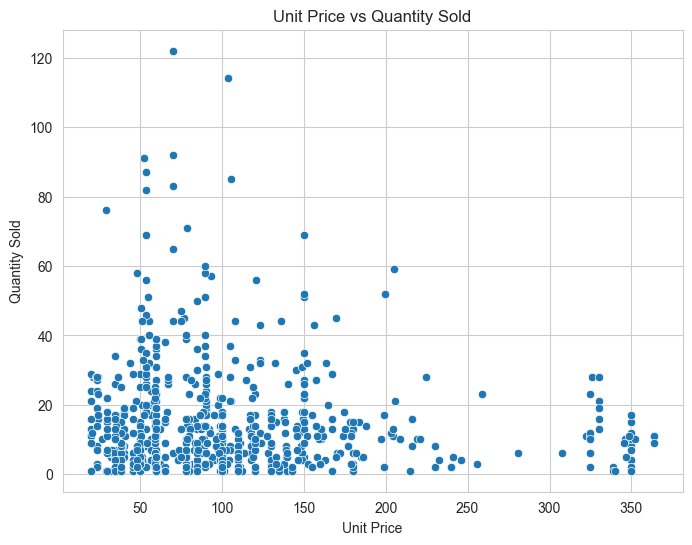

In [7]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="unit_price",
    y="qty"
)

plt.title("Unit Price vs Quantity Sold")
plt.xlabel("Unit Price")
plt.ylabel("Quantity Sold")

plt.show()

### Insight

- The scatter plot indicates a **negative relationship** between unit price and quantity sold.
- As the unit price increases, the quantity sold generally decreases.
- Several clusters are visible, suggesting groups of products with similar pricing and demand.
- A few outlier products behave differently from the majority and may require further investigation.

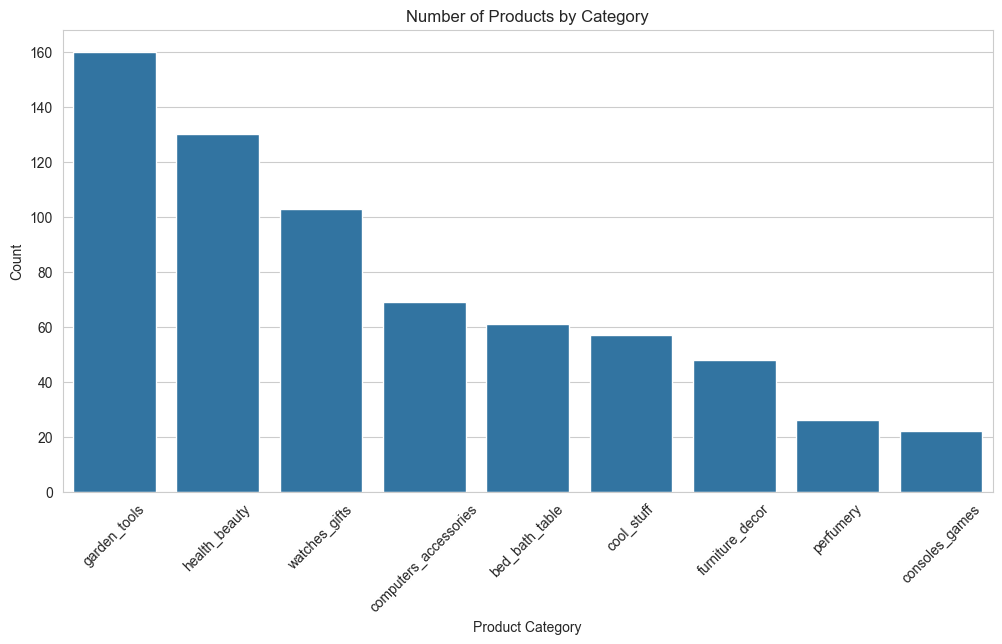

In [8]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="product_category_name",
    order=df["product_category_name"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Number of Products by Category")
plt.xlabel("Product Category")
plt.ylabel("Count")

plt.show()

### Insight

- Garden Tools is the most represented product category in the dataset.
- Consoles Games has the fewest records.
- This suggests the retailer offers a wider variety of Garden Tools products.
- However, a higher number of products does not necessarily imply higher sales or revenue.

### 6. Correlation Analysis

The heatmap below is used to examine linear relationships between numerical variables. Understanding these relationships helps identify influential features for demand prediction and supports feature selection for machine learning models.

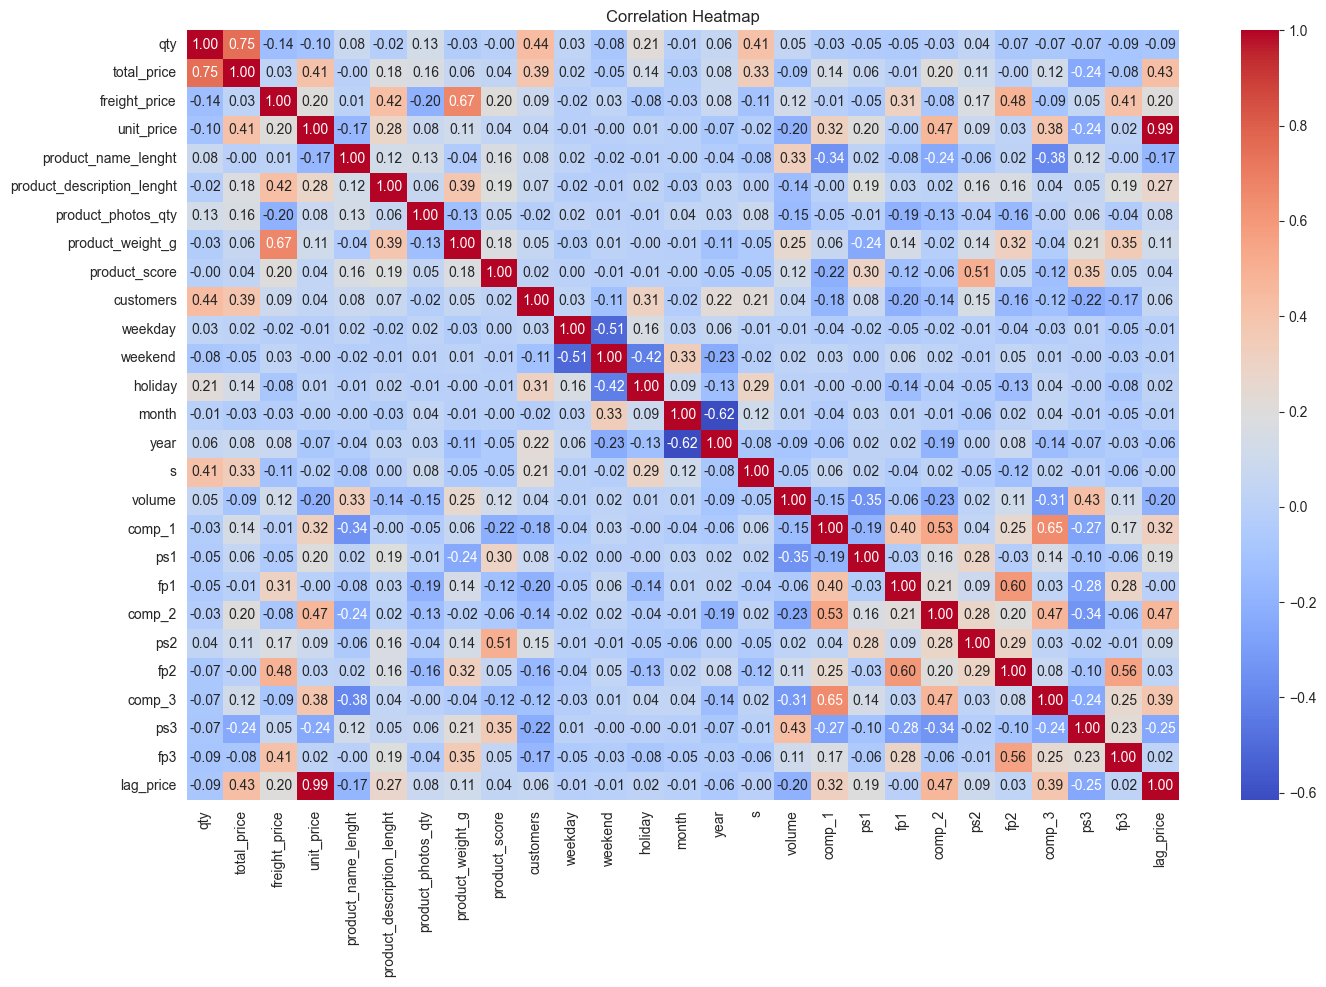

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Insights

- Variables with strong positive correlations tend to increase together.
- Variables with strong negative correlations move in opposite directions.
- Features with weak correlations have little or no linear relationship.
- The heatmap helps identify important predictors for demand forecasting and price optimization.
- No conclusions about causation should be made solely based on correlation.

## 7. Monthly Sales Trend

Analyze the monthly sales trend to identify seasonal patterns and fluctuations in product demand over time.

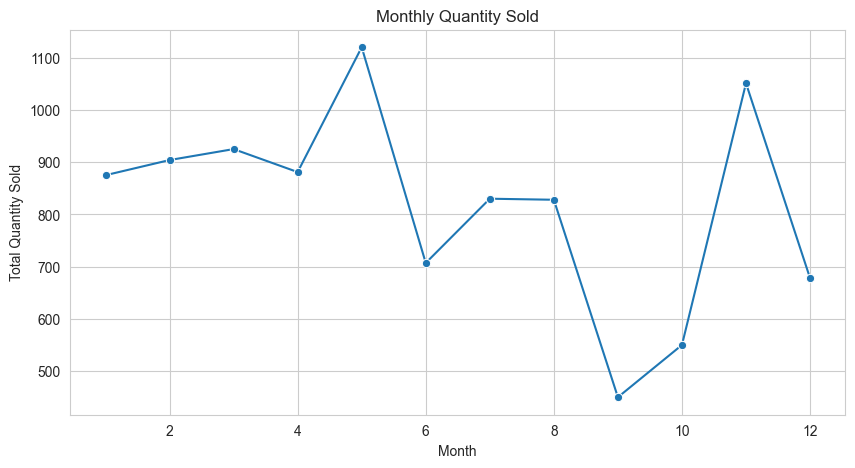

In [10]:
monthly_sales = df.groupby("month")["qty"].sum()

plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o"
)

plt.title("Monthly Quantity Sold")
plt.xlabel("Month")
plt.ylabel("Total Quantity Sold")

plt.show()

### Insights

- The line chart shows how total quantity sold changes across different months.
- Peaks indicate periods of higher demand, while dips represent lower sales periods.
- Understanding monthly demand patterns can support inventory planning and pricing decisions.

## 8. Top Categories by Quantity Sold

Identify the product categories that contribute the highest sales volume.


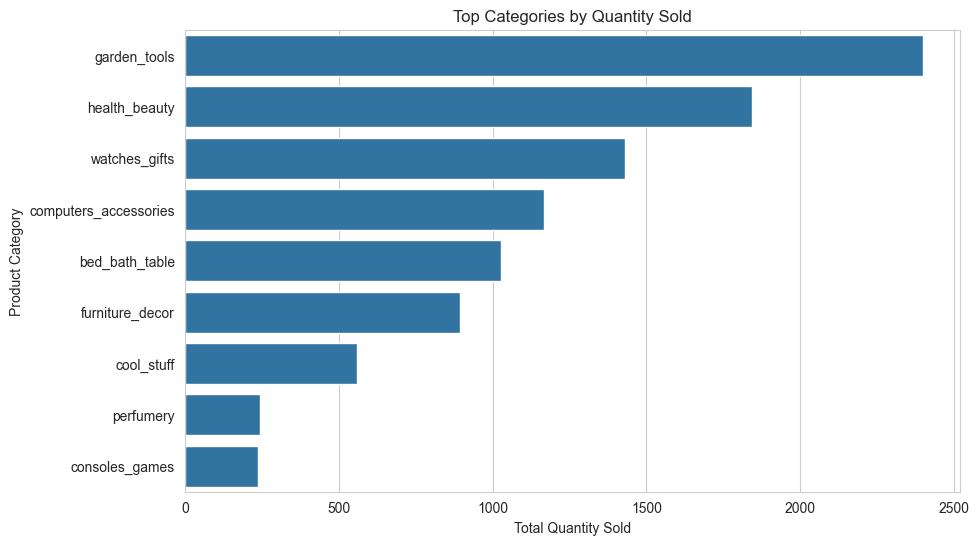

In [11]:
top_categories = (
    df.groupby("product_category_name")["qty"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title("Top Categories by Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product Category")

plt.show()

### Insights

- Some product categories contribute significantly more to total sales than others.
- High-performing categories may require better inventory management and pricing strategies.
- Low-performing categories can be analyzed for possible improvements or promotional opportunities.

## 9. Revenue Distribution

Analyze how revenue is distributed across all transactions.


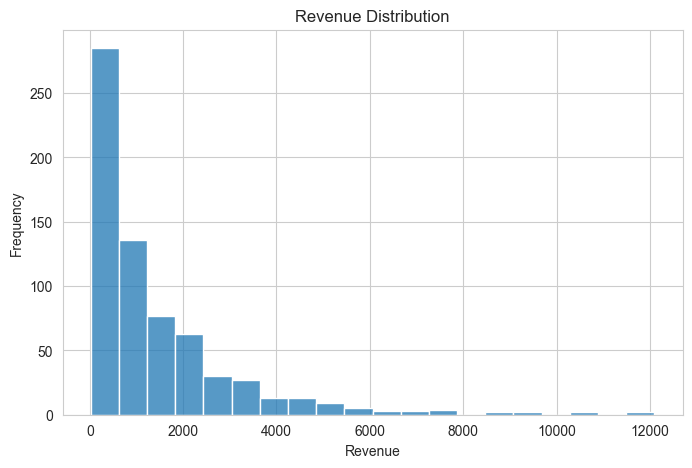

In [12]:
df["revenue"] = df["qty"] * df["unit_price"]

plt.figure(figsize=(8,5))

sns.histplot(df["revenue"], bins=20)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.show()

### Insights

- Most transactions generate relatively lower revenue.
- A small number of transactions contribute disproportionately higher revenue.
- Identifying high-revenue products can help maximize profitability.

## 10. Competitor Price Comparison

Compare the company's product prices with competitor prices.


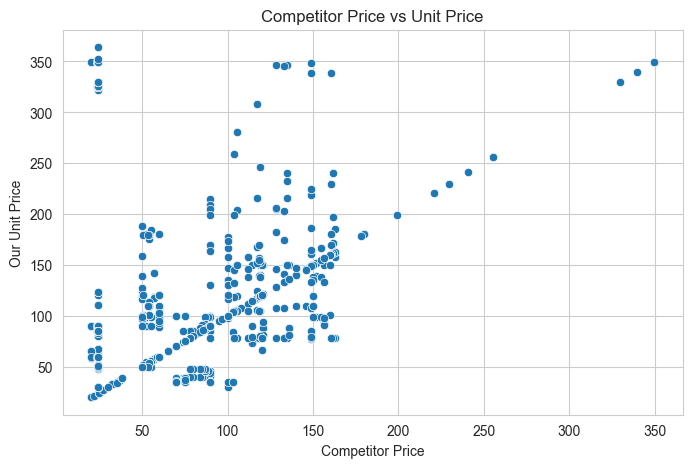

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="comp_1",
    y="unit_price"
)

plt.title("Competitor Price vs Unit Price")
plt.xlabel("Competitor Price")
plt.ylabel("Our Unit Price")

plt.show()

### Insights

- The scatter plot highlights the relationship between competitor prices and our product prices.
- Products positioned far from the general trend may require pricing review.
- This comparison provides useful information for competitive pricing strategies.

## 11. Average Quantity Sold by Category

Compare the average demand across different product categories.

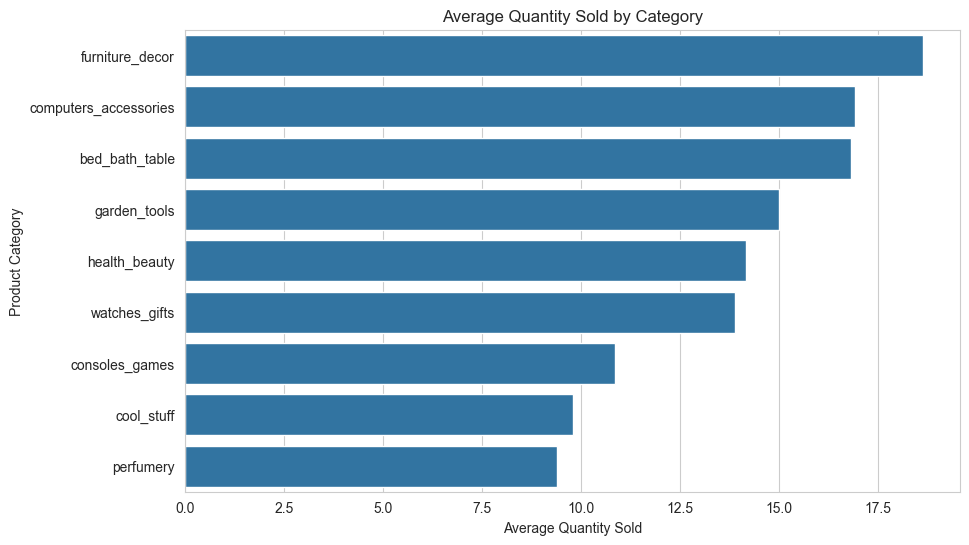

In [14]:
avg_qty = (
    df.groupby("product_category_name")["qty"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=avg_qty.values,
    y=avg_qty.index
)

plt.title("Average Quantity Sold by Category")
plt.xlabel("Average Quantity Sold")
plt.ylabel("Product Category")

plt.show()

### Insights

- Product categories differ considerably in their average demand.
- Categories with consistently higher average sales may contribute more to stable revenue.
- These insights can support product assortment and inventory planning.

## 12. Average Unit Price by Category

Compare the average selling price across different product categories.


In [ ]:
avg_price = (
    df.groupby("product_category_name")["unit_price"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=avg_price.values,
    y=avg_price.index
)

plt.title("Average Unit Price by Category")
plt.xlabel("Average Unit Price")
plt.ylabel("Product Category")

plt.show()

### Insights

- Product categories exhibit different pricing strategies.
- Some categories contain premium-priced products, while others focus on lower-priced items.
- Understanding category-level pricing supports better pricing optimization decisions.